In [28]:

from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, Normalize
import numpy as np
import matplotlib.pyplot as plt
import mpl_scatter_density


data = np.load("../../../_test/2024-05-28--08-12-27/archive.npz")

results = {}

for experiment in data.keys():
    experiment_parameters = data[experiment]["reboot_seed"]["experiment_parameters"][0]
    shape = experiment_parameters["shape"]

    if shape[0] in results:
        results[shape[0]].append(data[experiment])
    else:
        results[shape[0]] = [data[experiment]]

z_order = experiment_parameters['z_order']
roots_of_unity = np.array([[np.cos(2 * np.pi * i / z_order),
                                np.sin(2 * np.pi * i / z_order)] for i in range(z_order)])



lattice_sizes = []

result_keys = list(results.keys())
result_keys.sort()


time_series = {}
tin_data = {}
pp_correlators = {}

for shape in result_keys:
    results[shape].sort(key=lambda x: x["reboot_seed"]["experiment_parameters"]["beta"])


    results[shape] = np.array(results[shape])

    rec_shape = results[shape]["ploop_corr_recordings"]["polyakov_loops"].shape

    _,_,number_rec, x_dim, y_dim, z_dim = rec_shape


    loops = results[shape]["ploop_corr_recordings"]["polyakov_loops"]
    loops = roots_of_unity[loops]

    # Tin Data
    temp = loops.sum(axis=(3,4,5))
    tin_snapshot = np.linalg.norm(temp, axis=-1)  
    tin_snapshot = tin_snapshot.sum(axis=(1,2))/(number_rec*x_dim*y_dim*z_dim)
    tin_data[x_dim]= tin_snapshot

    # Time series
    time_serie = loops.sum(axis=(3,4,5)).squeeze(axis=1)/(x_dim*y_dim*z_dim)
    time_series[x_dim] = time_serie

    betas = results[shape]["reboot_seed"]["experiment_parameters"]["beta"].squeeze()

    lattice_sizes.append(x_dim)

    pp_correlators[x_dim] = results[shape]["ploop_corr_recordings"]["pp_correlators"]

 


# save the data
np.savez("../../../temp/transfer_data", time_series=time_series, tin_data=tin_data, betas=betas, lattice_sizes=lattice_sizes,pp_correlators=pp_correlators)
    





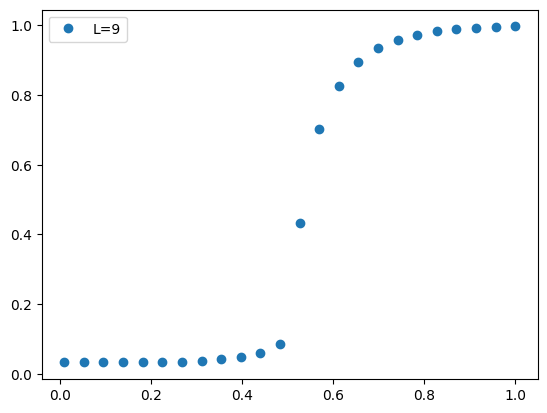

In [29]:
data = np.load("../../../temp/transfer_data.npz", allow_pickle=True)

tin_data = data["tin_data"].item()
betas = data["betas"]

fig, ax = plt.subplots()

for key in tin_data.keys():
    ax.plot(betas, tin_data[key], 'o', label=f"L={key}")

ax.legend()
plt.show()

/Users/landa/Documents/GitHub/crunchy/myenv/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/Users/landa/Documents/GitHub/crunchy/myenv/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


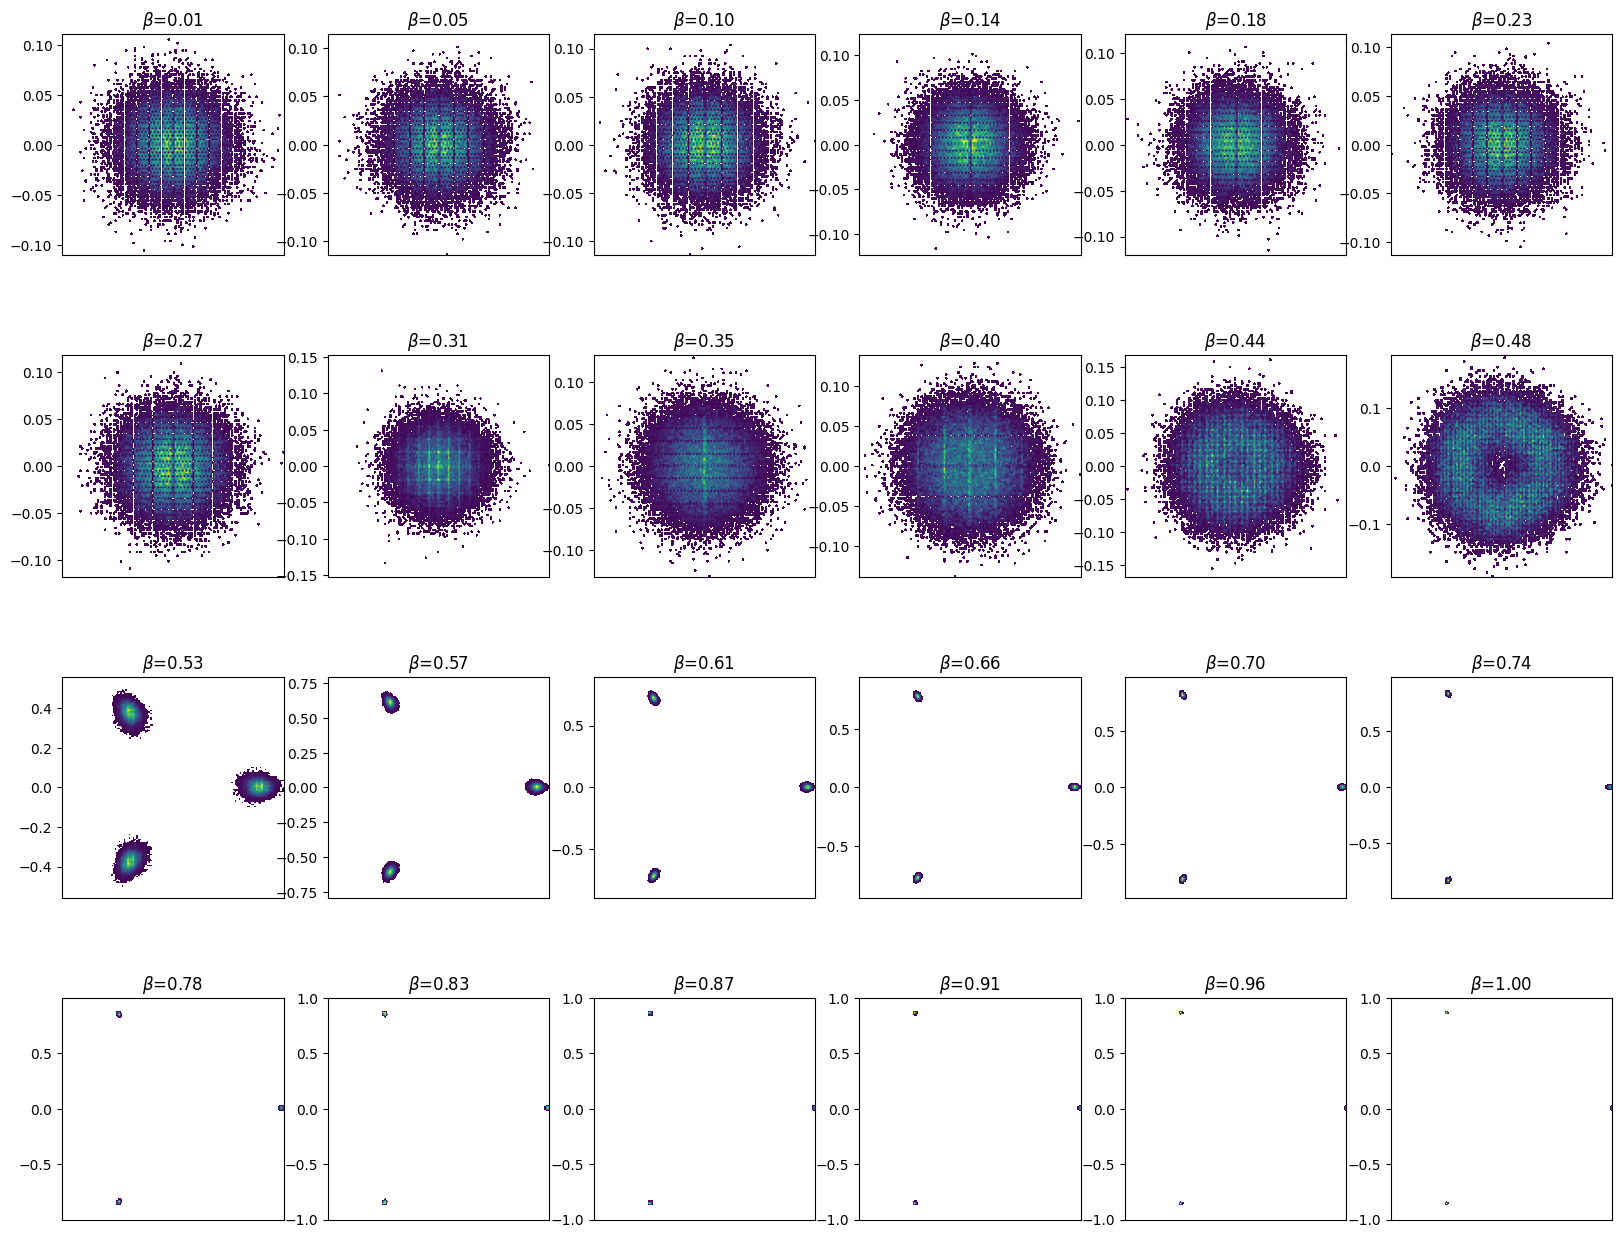

In [71]:
data = np.load("../../../temp/transfer_data.npz", allow_pickle=True)

time_series = data["time_series"].item()

rows = 4
columns = 6


fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(rows, columns)

axes = []

white_viridis = LinearSegmentedColormap.from_list('white_viridis', [
    (0, '#ffffff'),
    (1e-20, '#440053'),
    (0.2, '#404388'),
    (0.4, '#2a788e'),
    (0.6, '#21a784'),
    (0.8, '#78d151'),
    (1, '#fde624'),
], N=256)

betas = data["betas"]

for i in range(rows):
    for j in range(columns):
        axes.append(fig.add_subplot(
            gs[i, j], projection='scatter_density'))
        axes[-1].set_aspect('equal', 'box')
        # axes[-1].set_xticks([])
        #axes[-1].set_yticks([])


        time_serie = time_series[9][i*columns+j]

        cutoff = 100
        time_serie = time_serie[cutoff:]

        time_serie_rotated = time_serie.copy()
        rotation_matrix = np.array([[np.cos(2 * np.pi / 3), -np.sin(2 * np.pi / 3)], [
                                    np.sin(2 * np.pi / 3), np.cos(2 * np.pi / 3)]])

        time_serie_rotated = np.dot(time_serie, rotation_matrix)
        time_serie = np.concatenate([time_serie, time_serie_rotated])

        time_serie_rotated = np.dot(time_serie_rotated, rotation_matrix)
        time_serie = np.concatenate([time_serie, time_serie_rotated])

        x = time_serie[:, 0]
        y = time_serie[:, 1]

        # find max radius
        max_radius = np.max(np.linalg.norm(time_serie, axis=-1))

        axes[-1].set_xticks([])
        
        # # normalize
        # x = x / max_radius
        # y = y / max_radius

        
        axes[-1].set_xlim(-max_radius, max_radius)
        axes[-1].set_ylim(-max_radius, max_radius)
        
        axes[-1].scatter_density(x, y, cmap=white_viridis, dpi=70)

        axes[-1].set_xlim(-max_radius, max_radius)
        axes[-1].set_ylim(-max_radius, max_radius)

        radius = 1

       
        axes[-1].set_title(r"$\beta$={:.2f}".format(betas[i*columns+j]))


plt.savefig("evo_circles.pdf")


In [3]:
import numpy as np

data = np.load("../../../_recordings/Z_3_lamblda_sweep_2024-05-29--14-34-19/archive.npz", allow_pickle=True)


results = {}

results = {}

for experiment in data.keys():
    experiment_parameters = data[experiment]["reboot_seed"]["experiment_parameters"][0]
    shape = experiment_parameters["shape"]

    if shape[0] in results:
        results[shape[0]].append(data[experiment])
    else:
        results[shape[0]] = [data[experiment]]

z_order = experiment_parameters['z_order']
roots_of_unity = np.array([[np.cos(2 * np.pi * i / z_order),
                                np.sin(2 * np.pi * i / z_order)] for i in range(z_order)])



lattice_sizes = []

result_keys = list(results.keys())
result_keys.sort()


time_series = {}
tin_data = {}
pp_correlators = {}

for shape in result_keys:
    results[shape].sort(key=lambda x: x["reboot_seed"]["experiment_parameters"]["beta"])


    results[shape] = np.array(results[shape])

    rec_shape = results[shape]["ploop_corr_recordings"]["polyakov_loops"].shape

    _,_,number_rec, x_dim, y_dim, z_dim = rec_shape


    loops = results[shape]["ploop_corr_recordings"]["polyakov_loops"]
    loops = roots_of_unity[loops]

    # Tin Data
    temp = loops.sum(axis=(3,4,5))
    tin_snapshot = np.linalg.norm(temp, axis=-1)  
    tin_snapshot = tin_snapshot.sum(axis=(1,2))/(number_rec*x_dim*y_dim*z_dim)
    tin_data[x_dim]= tin_snapshot

    # Time series
    time_serie = loops.sum(axis=(3,4,5)).squeeze(axis=1)/(x_dim*y_dim*z_dim)
    time_series[x_dim] = time_serie

    betas = results[shape]["reboot_seed"]["experiment_parameters"]["beta"].squeeze()

    lattice_sizes.append(x_dim)

    pp_correlators[x_dim] = results[shape]["ploop_corr_recordings"]["pp_correlators"]


np.savez("transfer_data", time_series=time_series, tin_data=tin_data, betas=betas, lattice_sizes=lattice_sizes,pp_correlators=pp_correlators)

 


[0.01       0.05304348 0.09608696 0.13913044 0.18217392 0.2252174
 0.26826087 0.31130433 0.35434783 0.39739132 0.44043478 0.48347825
 0.52652174 0.56956524 0.6126087  0.65565217 0.69869566 0.74173915
 0.78478265 0.8278261  0.8708696  0.9139131  0.9569565  1.        ]


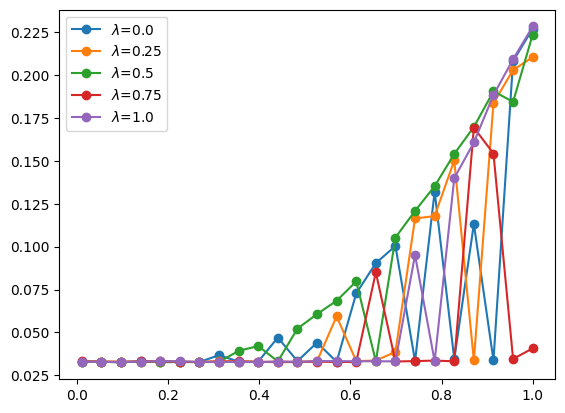

In [26]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("transfer_data.npz", allow_pickle=True)

tin_data = data["tin_data"].item()[9]
betas = data["betas"][::5]

print(betas)



lambdas = [0.0, 0.25, 0.5, 0.75, 1.0]

lambda_data = {}
for (i, l) in enumerate(lambdas):
    temp = {}
    temp["tin_data"] = np.array(tin_data[i::5])

    lambda_data[l] = temp

for key in lambda_data.keys():
    # if key != 1.0:
    #     continue
    plt.plot(betas, lambda_data[key]["tin_data"], '-o', label=f"$\lambda$={key}")

plt.legend()
plt.show()
    









In [37]:

from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, Normalize
import numpy as np
import matplotlib.pyplot as plt
import mpl_scatter_density


def produce_data(archive_path, transfer_file_name):

    # data = np.load("../../../_recordings/2024-05-29--17-17-40/archive.npz")
    data = np.load(archive_path)

    results = {}

    for experiment in data.keys():
        experiment_parameters = data[experiment]["reboot_seed"]["experiment_parameters"][0]
        shape = experiment_parameters["shape"]

        if shape[0] in results:
            results[shape[0]].append(data[experiment])
        else:
            results[shape[0]] = [data[experiment]]

    z_order = experiment_parameters['z_order']
    roots_of_unity = np.array([[np.cos(2 * np.pi * i / z_order),
                                    np.sin(2 * np.pi * i / z_order)] for i in range(z_order)])



    lattice_sizes = []

    result_keys = list(results.keys())
    result_keys.sort()


    time_series = {}
    tin_data = {}
    pp_correlators = {}

    for shape in result_keys:
        results[shape].sort(key=lambda x: x["reboot_seed"]["experiment_parameters"]["beta"])


        results[shape] = np.array(results[shape])

        rec_shape = results[shape]["ploop_corr_recordings"]["polyakov_loops"].shape

        _,_,number_rec, x_dim, y_dim, z_dim = rec_shape


        loops = results[shape]["ploop_corr_recordings"]["polyakov_loops"]
        loops = roots_of_unity[loops]

        # Tin Data
        temp = loops.sum(axis=(3,4,5))
        tin_snapshot = np.linalg.norm(temp, axis=-1)  
        tin_snapshot = tin_snapshot.sum(axis=(1,2))/(number_rec*x_dim*y_dim*z_dim)
        tin_data[x_dim]= tin_snapshot

        # Time series
        time_serie = loops.sum(axis=(3,4,5)).squeeze(axis=1)/(x_dim*y_dim*z_dim)
        time_series[x_dim] = time_serie

        betas = results[shape]["reboot_seed"]["experiment_parameters"]["beta"].squeeze()

        lattice_sizes.append(x_dim)

        pp_correlators[x_dim] = results[shape]["ploop_corr_recordings"]["pp_correlators"]

    


    # save the data
    np.savez(transfer_file_name, time_series=time_series, tin_data=tin_data, betas=betas, lattice_sizes=lattice_sizes,pp_correlators=pp_correlators)
        

folder_names = ["../../../_recordings/2024-05-29--17-17-40/archive.npz","../../../_recordings/2024-05-29--17-18-37/archive.npz","../../../_recordings/2024-05-29--17-18-46/archive.npz", "../../../_recordings/2024-05-29--17-19-41/archive.npz", "../../../_test/2024-05-28--08-12-27/archive.npz"]

for (i, folder_name) in enumerate(folder_names):
    produce_data(folder_name, f"transfer_data_{i}")


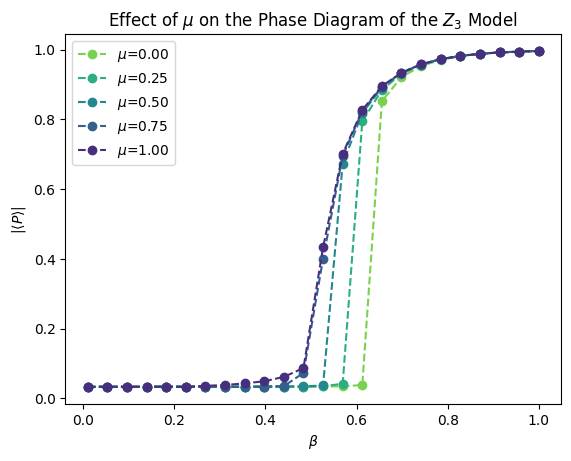

In [69]:
betas = data["betas"]

fig, ax = plt.subplots()
lambdas = [0.0, 0.25, 0.5, 0.75, 1.0]

# use viridis for the color map
viridis = plt.cm.viridis
cmap = viridis
norm = Normalize(vmin=0, vmax=6)

for (i, folder_name) in enumerate(folder_names):
    data = np.load(f"transfer_data_{i}.npz", allow_pickle=True)
    tin_data = data["tin_data"].item()

    for key in tin_data.keys():
        ax.plot(betas, tin_data[key], '--o', label=r"$\mu$={:.2f}".format(lambdas[i]), color=cmap(-0.2+1-norm(i)))


ax.set_title("Effect of $\mu$ on the Phase Diagram of the $Z_3$ Model") 
ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"$| \langle P \rangle |$")

plt.savefig("effect_of_mu.pdf")

ax.legend()
plt.show()

